In [ ]:
from google.colab import drive
import os
import shutil

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================
# STEP 1: Imports
# ============================================
import os
import numpy as np
import pandas as pd
from glob import glob
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model

# ============================================
# STEP 2: Dataset Path
# ============================================
data_dir = "/content/drive/MyDrive/Images DataBase/Images DataBase"  # <-- update path

# ============================================
# STEP 3: Load Dataset (images + labels)
# ============================================
img_size = (224, 224)
batch_size = 32

dataset = image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

# Get class names
class_names = dataset.class_names
print("Classes:", class_names)

# Extract images and labels as numpy arrays
X = []
y = []
for imgs, labels in dataset:
    X.append(imgs.numpy())
    y.append(labels.numpy())

X = np.vstack(X)
y = np.hstack(y)

print("Image array shape:", X.shape)
print("Labels shape:", y.shape)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)
print("Encoded labels:", np.unique(y))

# ============================================
# STEP 4: Pretrained DenseNet201 Feature Extractor
# ============================================
base_model = DenseNet201(weights="imagenet", include_top=False, pooling="avg", input_shape=(224,224,3))
model = Model(inputs=base_model.input, outputs=base_model.output)

# Preprocess images
X_prep = preprocess_input(X)

# Extract embeddings
features = model.predict(X_prep, batch_size=32, verbose=1)
print("Feature shape:", features.shape)

# ============================================
# STEP 5: Cross-validation with Random Forest
# ============================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = []
fold = 1

for train_idx, test_idx in skf.split(features, y):
    X_train, X_test = features[train_idx], features[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Random Forest Classifier
    clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
    clf.fit(X_train, y_train)

    # Predictions
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    acc_scores.append(acc)

    print(f"\nFold {fold} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names))
    fold += 1

print("\nAverage CV Accuracy:", np.mean(acc_scores))


Found 1710 files belonging to 30 classes.
Classes: ['Person 10', 'Person 11', 'Person 12', 'Person 13', 'Person 14', 'Person 15', 'Person 16', 'Person 17', 'Person 18', 'Person 19', 'Person 20', 'Person 21', 'Person 22', 'Person 23', 'Person 24', 'Person 25', 'Person 26', 'Person 27', 'Person 28', 'Person 29', 'Person 30', 'Person 6', 'Person 7', 'Person 8', 'Person 9', 'person 1', 'person 2', 'person 3', 'person 4', 'person 5']
Image array shape: (1710, 224, 224, 3)
Labels shape: (1710,)
Encoded labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 441s 8s/step
Feature shape: (1710, 1920)

Fold 1 Accuracy: 0.8158
              precision    recall  f1-score   support

   Person 10       0.83      0.91      0.87        11
   Person 11       0.92      0.92      0.92        12
   Person 12       1.00      0.67      0.80        12
   Person 13       0.83      0.91   

Found 1710 files belonging to 30 classes.
X_raw shape: (1710, 224, 224, 3)
Labels shape: (1710,)
54/54 ━━━━━━━━━━━━━━━━━━━━ 447s 8s/step
Feature shape: (1710, 1920)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_708']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


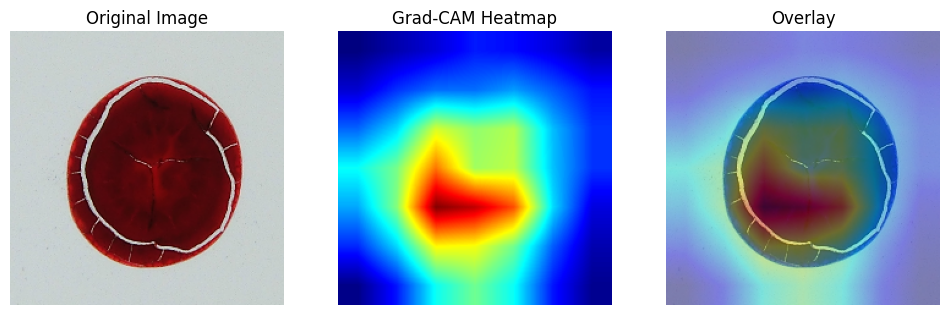

In [ ]:
# ============================================
# STEP 1: Imports
# ============================================
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory
import tensorflow as tf

# ============================================
# STEP 2: Dataset Path & Load Images
# ============================================
data_dir = "/content/drive/MyDrive/Images DataBase/Images DataBase"  # update path
img_size = (224, 224)
batch_size = 32

dataset = image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

# Save raw RGB images + labels
X_raw = []   # store original RGB images
y = []
for imgs, labels in dataset:
    X_raw.append(imgs.numpy())   # tf dataset gives float32 already 0–255
    y.append(labels.numpy())

X_raw = np.vstack(X_raw)  # shape (n_samples, 224,224,3)
y = np.hstack(y)

print("X_raw shape:", X_raw.shape)
print("Labels shape:", y.shape)

# ============================================
# STEP 3: DenseNet Feature Extractor
# ============================================
base_model = DenseNet201(weights="imagenet", include_top=False, pooling="avg", input_shape=(224,224,3))
model = Model(inputs=base_model.input, outputs=base_model.output)

# Preprocess images for DenseNet
X_prep = preprocess_input(X_raw.copy())

# Extract features for RF later
features = model.predict(X_prep, batch_size=32, verbose=1)
print("Feature shape:", features.shape)

# ============================================
# STEP 4: Grad-CAM Function
# ============================================
def grad_cam(model, img_rgb, layer_name, preprocess_fn, alpha=0.4):
    """
    model: keras model
    img_rgb: single image RGB 224x224x3, 0-255
    layer_name: last conv layer name
    preprocess_fn: model's preprocess_input
    """
    # Preprocess single image for model (✅ fixed parenthesis)
    img_array = np.expand_dims(preprocess_fn(img_rgb.copy()), axis=0)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    # Normalize heatmap
    heatmap = np.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    # Resize to original image size
    heatmap = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    # Apply colormap
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img_rgb.astype(np.uint8), 1-alpha, heatmap_color, alpha, 0)

    return heatmap_color, overlay

# ============================================
# STEP 5: Example Grad-CAM on one image
# ============================================
idx = 0  # index of the image you want to visualize
img_rgb = np.uint8(X_raw[idx])  # make sure uint8 for display

heatmap, overlay = grad_cam(
    model,
    img_rgb,
    layer_name='conv5_block32_concat',  # last conv layer
    preprocess_fn=preprocess_input,
    alpha=0.4
)

# Plot
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_rgb.astype(np.uint8))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM Heatmap")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Overlay")
plt.axis('off')
plt.show()


In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

data_dir = "/content/drive/MyDrive/Images DataBase/Images DataBase"  # update if needed
img_size = (224, 224)
batch_size = 32

train_ds = image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 1710 files belonging to 30 classes.
Classes: ['Person 10', 'Person 11', 'Person 12', 'Person 13', 'Person 14', 'Person 15', 'Person 16', 'Person 17', 'Person 18', 'Person 19', 'Person 20', 'Person 21', 'Person 22', 'Person 23', 'Person 24', 'Person 25', 'Person 26', 'Person 27', 'Person 28', 'Person 29', 'Person 30', 'Person 6', 'Person 7', 'Person 8', 'Person 9', 'person 1', 'person 2', 'person 3', 'person 4', 'person 5']


In [ ]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras import layers, Model
import tensorflow as tf

# Base model
base_model = DenseNet201(weights="imagenet", include_top=False, pooling="avg", input_shape=(224,224,3))

# Freeze backbone first
base_model.trainable = False

# Add classification head
x = base_model.output
preds = layers.Dense(len(class_names), activation="softmax")(x)

clf_model = Model(inputs=base_model.input, outputs=preds)
clf_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

clf_model.summary()


Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_6    │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_6… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_7    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_7… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 18,379,614 (70.11 MB)

 Trainable params: 57,630 (225.12 KB)

 Non-trainable params: 18,321,984 (69.89 MB)

In [ ]:
history = clf_model.fit(train_ds, epochs=5)  # increase epochs later


Epoch 1/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 512s 9s/step - accuracy: 0.0619 - loss: 6.6909
Epoch 2/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 499s 9s/step - accuracy: 0.3358 - loss: 2.3232
Epoch 3/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 479s 9s/step - accuracy: 0.4274 - loss: 1.8467
Epoch 4/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 502s 9s/step - accuracy: 0.4971 - loss: 1.7304
Epoch 5/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 492s 9s/step - accuracy: 0.5531 - loss: 1.4335


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    heatmap = np.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_2125']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


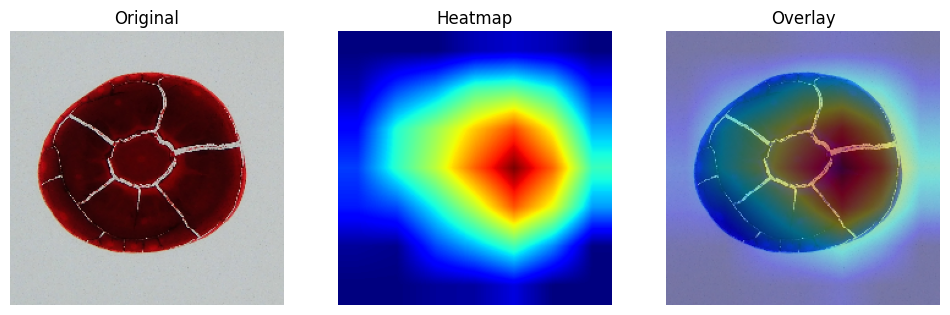

In [ ]:
# Pick one image
idx = 0
img_rgb = np.uint8(next(iter(train_ds))[0][idx].numpy())  # take image from dataset

img_input = np.expand_dims(tf.keras.applications.densenet.preprocess_input(img_rgb.copy()), axis=0)

# Get heatmap
heatmap = make_gradcam_heatmap(img_input, clf_model, "conv5_block32_concat")

# Overlay
heatmap = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
overlay = cv2.addWeighted(img_rgb.astype(np.uint8), 0.6, heatmap_color, 0.4, 0)

# Plot
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap="jet")
plt.title("Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Overlay")
plt.axis("off")
plt.show()


IndexError: index 1713 is out of bounds for axis 0 with size 1710

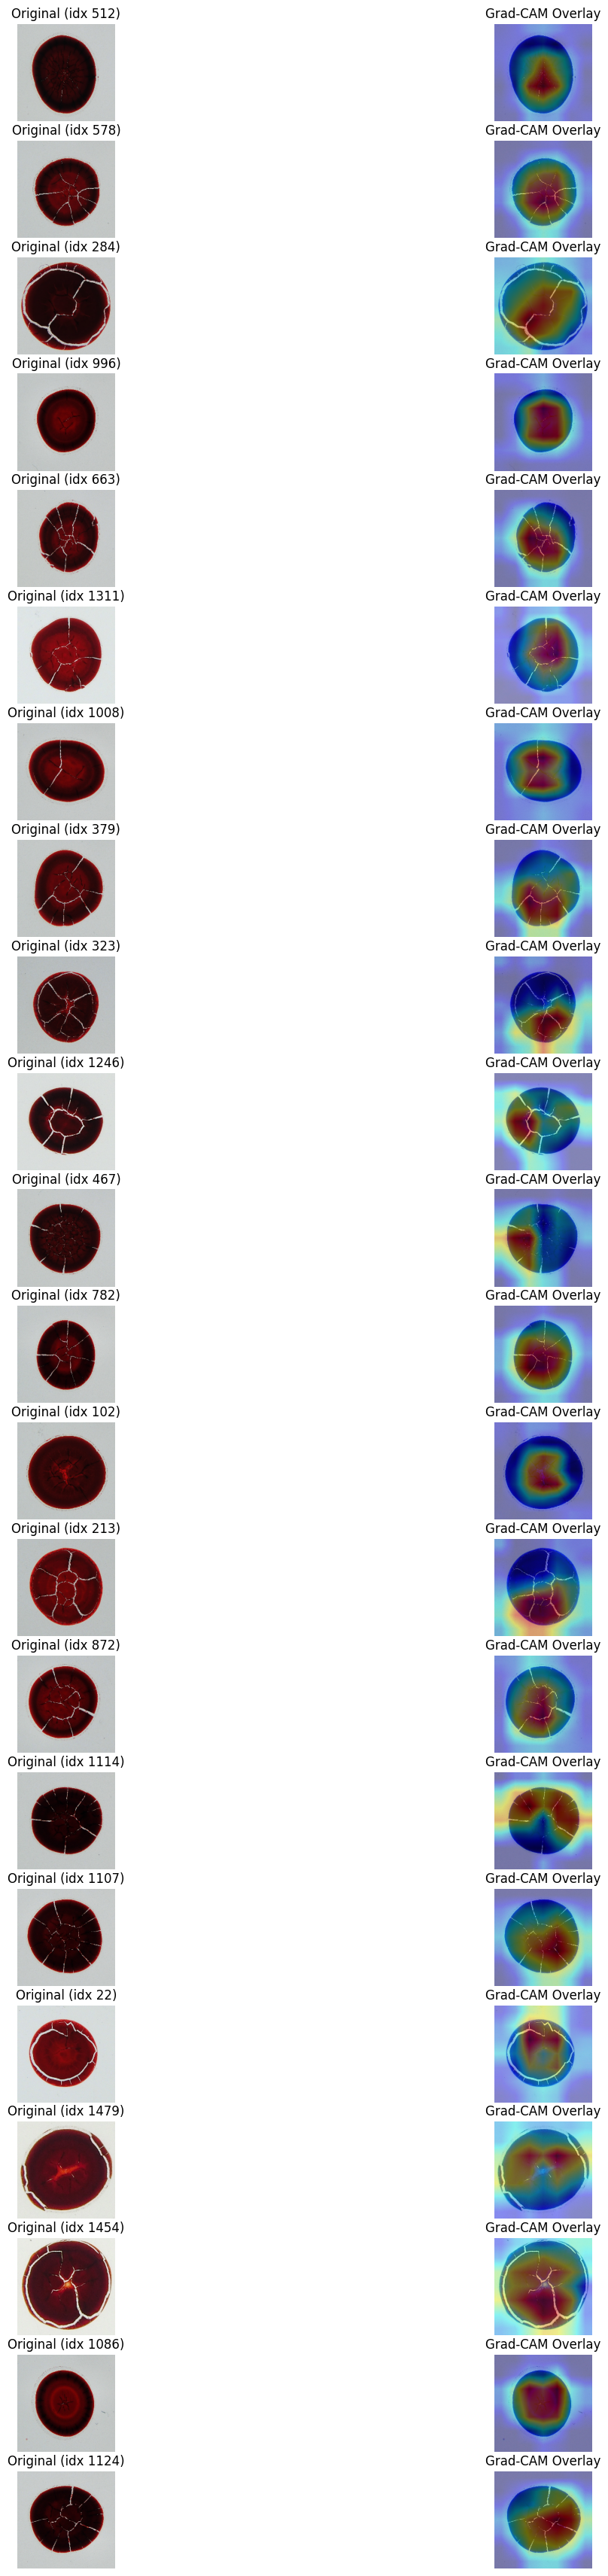

In [ ]:
import random

random_indices = random.sample(range(len(train_ds)*batch_size), 30)  # pick 30

plt.figure(figsize=(15, 60))

for i, idx in enumerate(random_indices):
    img_rgb = np.uint8(X_raw[idx])   # you already saved all images in X_raw earlier
    img_input = np.expand_dims(tf.keras.applications.densenet.preprocess_input(img_rgb.copy()), axis=0)

    heatmap = make_gradcam_heatmap(img_input, clf_model, "conv5_block32_concat")

    heatmap = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img_rgb.astype(np.uint8), 0.6, heatmap_color, 0.4, 0)

    plt.subplot(30, 2, 2*i+1)
    plt.imshow(img_rgb)
    plt.title(f"Original (idx {idx})")
    plt.axis("off")

    plt.subplot(30, 2, 2*i+2)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()
